In [19]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

In [2]:
TARGET_PATHS = {"perturbation_prediction_path": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl", 
               "ct_classifier_path": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2026-04-08_00-00-38/easy-monkey-341_TargetPredictionModel.pkl", 
               "prior_flow_path":"/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_matching/2026-04-04_10-19-42/woven-dawn-22_FlowMatchingWithScore.pkl", 
               "prior_flow_map_path": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_map/2026-04-13_11-57-30/copper-thunder-24_FlowMap.pkl"}

## Read annotation file

In [3]:
# Annotation file for protocols 
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [4]:
path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_official")
paths = os.listdir(path_to_results)

In [5]:
# cell_types = ["CD14Mono",
#                 "CD16Mono",
#                 "CyclingPro1",
#                 "CyclingPro2",
#                 "EosBasMast1",
#                 "EosBasMast2",
#                 "EosBasMast3",
#                 "EryPro",
#                 "HSCs",
#                 "ProB",
#                 "late_MgkPro",
#                 "GMP-Neutro",
#                 "preProB",
#                 "pre_cDC1"]

cell_types = ["EryPro",
                "HSCs",
                "ProB",
                "late_MgkPro",
                "preProB"]

In [6]:
pure_cell_type_solution_dict = {cell_type: [] 
                                for cell_type in cell_types
                               }

for experiment_folder in tqdm(paths):
    # Only consider pure populations 
    if "pure" in experiment_folder:
        cell_type_file_paths = path_to_results / experiment_folder
        # For all cell types 
        for cell_type in os.listdir(cell_type_file_paths):
            config_exp_folders = cell_type_file_paths / cell_type
            # For all the experiments in the folders 
            for config_exp_folder in os.listdir(config_exp_folders):
                # Be sure candidates are there 
                if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                    path = config_exp_folders / config_exp_folder / "candidates.csv"
                    candidate_with_uncertainty_df = pd.read_csv(path)
                    candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                    pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)

                    # Load yaml and check paths
                    config_path = Path(config_exp_folders) / config_exp_folder / "config.yaml"
                    with open(config_path, "r") as f:
                        config = yaml.safe_load(f)
                    
                    for path_type in config["paths"]:
                        if path_type != "dump_dir":
                            assert config["paths"][path_type] == TARGET_PATHS[path_type]
                    

100%|██████████| 6/6 [06:10<00:00, 61.68s/it]


In [7]:
# Concatenate data frame 
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict.items()
}

In [8]:
for col in pure_cell_type_solution_dict_concat["HSCs"].columns:
    print(col)

sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
loss
CD14Mono_prop
CD16Mono_prop
CyclingPro1_prop
CyclingPro2_prop
Early_GMP_prop
EosBasMast1_prop
EosBasMast2_prop
EosBasMast3_prop
EryPro_prop
GMP-Neutro_prop
GMP_cycling_prop
HSCs_prop
LMPP-CLP_prop
MLP_prop
MPP_prop
MPP_MgkEry_prop
MgKEryPro1_prop
MgKEryPro2_prop
ProB_prop
earlyMPP_prop
late_MgkPro_prop
preProB_prop
pre_cDC1_prop
pre_cDC2_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation:protocol_obsm_key
cfg:annotation:scatter_columns
cfg:annotation:base_sample_re

### Initialize targets

In [9]:
# Cell type fractions
celltype_fraction = {cell_type: 0 for cell_type in cell_types}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    # "loss", 
    # "target_ct_loss_std",
    # "target_ct_loss_mean",
    # "ct_prop_total_variance",
    # "exploitation_score",
    # "exploration_score",
    # "weighted_uncertainty_score",
    # "metric_response_surface", 
    # "indices",
    # "losses",
    # "acq_values"
]

In [10]:
for cell_type in cell_types:
    print(f"{cell_type} proportion", pure_cell_type_solution_dict_concat[cell_type][f"{cell_type}_prop"].max())

EryPro proportion 0.2506697
HSCs proportion 0.014621033
ProB proportion 0.0029985758
late_MgkPro proportion 0.85944074
preProB proportion 0.022196705


### Filter values

In [11]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [12]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered EryPro number of solutions: 45886
Unfiltered EryPro number of solutions: 62100 

Filtered HSCs number of solutions: 32424
Unfiltered HSCs number of solutions: 51700 

Filtered ProB number of solutions: 59616
Unfiltered ProB number of solutions: 72500 

Filtered late_MgkPro number of solutions: 45273
Unfiltered late_MgkPro number of solutions: 62800 

Filtered preProB number of solutions: 41612
Unfiltered preProB number of solutions: 62000 



In [13]:
filtered_df["HSCs"]["HSCs_prop"].max()

np.float64(0.014621033)

## Only keep solutions of correct cell types and analyze 

In [14]:
filtered_df = {key:val for key,val in filtered_df.items() if filtered_df[key].shape[0]>0 }

In [15]:
filtered_df.keys()

dict_keys(['EryPro', 'HSCs', 'ProB', 'late_MgkPro', 'preProB'])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


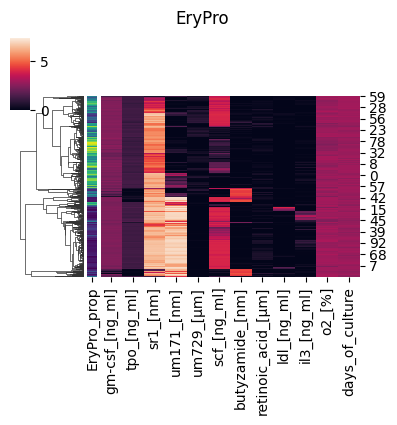

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


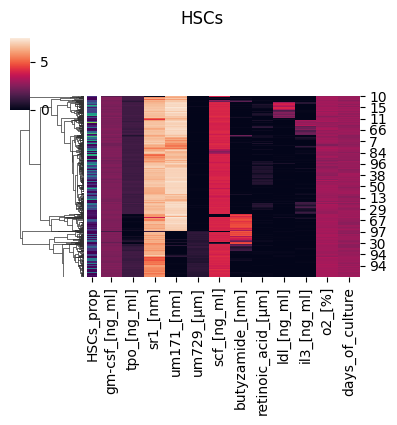

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


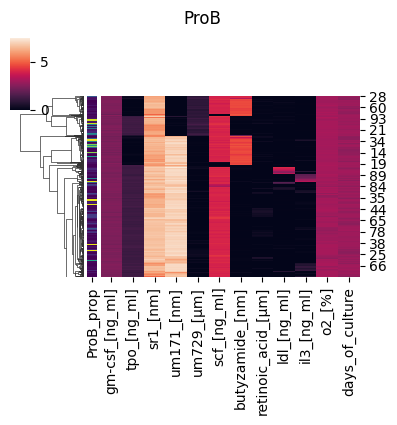

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


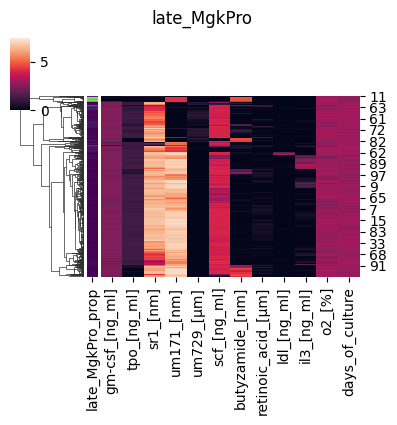

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


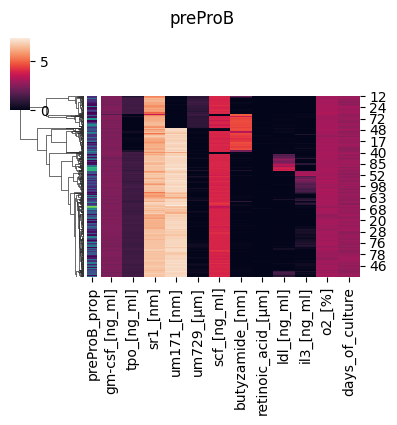

In [16]:
for cell_type in filtered_df:
    data = np.log1p(filtered_df[cell_type].loc[:, protocol_cols])
    
    # Get the annotation column
    prop_col = filtered_df[cell_type][f"{cell_type}_prop"]
    
    # Normalize + map to colors
    norm = plt.Normalize(prop_col.min(), prop_col.max())
    cmap = plt.cm.viridis
    row_colors = prop_col.map(lambda x: cmap(norm(x)))
    
    g = sns.clustermap(
        data,
        figsize=(4, 4),
        row_cluster=True,
        col_cluster=False,
        row_colors=row_colors  # <-- side annotation here
    )
    
    g.fig.suptitle(cell_type, y=1.05)
    plt.show()

## Check these protocols in the real data 

In [17]:
protocol_adata_real = sc.read_h5ad("protocol_adata.h5ad")

In [18]:
for cell_type in filtered_df:
    print(cell_type)
    
    # Get top 10 indices based on highest proportions
    top_idx = protocol_adata_real.obs[cell_type].nlargest(5).index
    
    
    # Subset using those indices
    obs_cell_type = protocol_adata_real[top_idx]
    print(np.exp(pd.DataFrame(obs_cell_type.X, columns=protocol_adata_real.var.index))-1)
    
    # obs_cell_type_X = pd.DataFrame(
    #     obs_cell_type.X, 
    #     columns=obs_cell_type.var.index
    # )
    
    # obs_cell_type_X = obs_cell_type_X.drop(
    #     columns=["740-yp_[µm]", "mtg_[µm]", "rhflt3l_[ng_ml]"]
    # )
    
    # g = sns.clustermap(
    #     obs_cell_type_X,
    #     figsize=(4, 4),
    #     row_cluster=True,
    #     col_cluster=False,
    # )
    # g.fig.suptitle(cell_type, y=1.05)
    # plt.show()

EryPro
   740-yp_[µm]  mtg_[µm]  rhflt3l_[ng_ml]  gm-csf_[ng_ml]  tpo_[ng_ml]  \
0          5.0     100.0             10.0            10.0          2.5   
1          5.0     100.0             10.0            10.0          2.5   
2          5.0     100.0             10.0            10.0          2.5   
3          5.0     100.0             10.0            10.0          2.5   
4          5.0     100.0             10.0            10.0          2.5   

   sr1_[nm]  um171_[nm]  um729_[µm]  scf_[ng_ml]  butyzamide_[nm]  \
0      75.0         0.0        0.75         50.0              0.0   
1     375.0         0.0        0.75         50.0              0.0   
2      75.0         0.0        0.75          0.0              0.0   
3     375.0         0.0        0.75          0.0              0.0   
4     750.0       280.0        0.00         50.0              0.0   

   retinoic_acid_[µm]  ldl_[ng_ml]  il3_[ng_ml]  o2_[%]  days_of_culture  
0                 0.0          0.0          0.0    20.0   